---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>CheckPoint05</strong></h2>
<h3 style="text-align: center;"><strong>Random Forest, XGBoost e LightGBM: modelagem, tuning, avaliação e deploy</strong></h3>
<h4 style="text-align: center;"><strong>Versão única</strong></h4>

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
.jp-MarkdownOutput p, .text_cell_render p,
.jp-MarkdownOutput li, .text_cell_render li {
    line-height: 1.6;
}
</style>

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Configuração visual:</strong> o notebook prioriza tipografia serifada para células Markdown. A renderização de CSS pode variar entre Jupyter Notebook, JupyterLab, VS Code e Google Colab; quando uma fonte não estiver disponível, o visualizador utilizará uma alternativa local. O código permanece com fonte monoespaçada do ambiente.
</div>

<br>

---

<br>

## **Identificação dos alunos**

A atividade deve ser realizada em **grupos de no máximo 5 alunos**. Preencha, abaixo, o nome e o RM de cada integrante do grupo. Caso o grupo tenha menos de cinco integrantes, mantenha sem preenchimento os campos não utilizados.


In [1]:
#@title Identificação
Nome_1 = "Leonardo Eiji Kina" #@param {type:"string"}
RM_1 = "562784" #@param {type:"string"}
Nome_2 = "Nicholas Braga de Souza" #@param {type:"string"}
RM_2 = "561733" #@param {type:"string"}
Nome_3 = "Tomé Rossi Giani" #@param {type:"string"}
RM_3 = "562422" #@param {type:"string"}
Nome_4 = "Vitor Ramos de Farias" #@param {type:"string"}
RM_4 = "561958" #@param {type:"string"}
Nome_5 = "" #@param {type:"string"}
RM_5 = "" #@param {type:"string"}

integrantes = [(Nome_1, RM_1), (Nome_2, RM_2), (Nome_3, RM_3),
               (Nome_4, RM_4), (Nome_5, RM_5)]
print("Integrantes do grupo:")
for i, (nome, rm) in enumerate(integrantes, start=1):
    if nome:
        print(f"  {i}. {nome} — RM {rm}")


Integrantes do grupo:
  1. Leonardo Eiji Kina — RM 562784
  2. Nicholas Braga de Souza — RM 561733
  3. Tomé Rossi Giani — RM 562422
  4. Vitor Ramos de Farias — RM 561958


<br>

---

<br>

# **CheckPoint05**

## **Objetivos**

- Estruturar um problema real de **classificação** ou **regressão** a partir de uma base de dados escolhida pelo grupo.
- Realizar **data wrangling**, análise exploratória e seleção justificada das variáveis preditoras.
- Implementar e comparar **Random Forest**, **XGBoost** e **LightGBM** sob o mesmo protocolo experimental.
- Ajustar hiperparâmetros com **Grid Search** e **Optuna**, sem utilizar o conjunto de teste durante a busca.
- Selecionar o melhor modelo com base em evidências quantitativas e analisar **overfitting** e **underfitting**.
- Avaliar o modelo final em dados não utilizados no desenvolvimento e construir um teste de consistência das previsões.
- Disponibilizar o projeto em um repositório **GitHub** e uma interface funcional em **Streamlit**.

## **Instruções**

- Leia cada enunciado com atenção.
- Observe a pontuação indicada em cada questão. A atividade vale **10 pontos** no total.
- O grupo deve escolher **um único problema** que possa ser tratado como classificação ou regressão e utilizar a mesma base em toda a atividade.
- A base pode ser pública, institucional autorizada ou coletada pelo grupo. A fonte, a licença ou a forma de obtenção devem ser documentadas.
- O problema deve produzir uma representação tabular de atributos e variável-alvo. Não utilize dados pessoais ou sensíveis sem autorização e justificativa acadêmica adequada.
- Sempre que necessário, registre o raciocínio antes da implementação em Python.
- Quando o item pedir interpretação, responda com base nos resultados obtidos, não apenas com definições genéricas.
- Responda os exercícios nos espaços indicados. Caso seja necessário, adicione células para complementar a resposta.
- Indique de forma organizada a solução dos exercícios.
- Preocupe-se em fazer um código Python limpo, documentado e reprodutível. Esse aspecto será avaliado ao longo de toda a atividade.
- O conjunto de **teste deve permanecer isolado** durante seleção de variáveis, comparação de modelos e tuning. Ele só poderá ser utilizado no Exercício 7.
- O envio da atividade deve incluir o notebook `.ipynb`, o link do repositório GitHub e o link da aplicação Streamlit.
- Cada grupo deverá realizar uma **apresentação oral da solução, com duração máxima de 10 minutos**, sintetizando o problema, as principais decisões metodológicas, a comparação entre os modelos, o modelo final e a demonstração da aplicação.
- Execute o notebook do início ao fim antes do envio. Ele não deve conter erros durante a execução.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Entregáveis obrigatórios:</strong> notebook final, repositório GitHub reproduzível, aplicação Streamlit funcional e **apresentação oral da solução com duração máxima de 10 minutos**. O repositório deve conter, no mínimo, README com instruções de execução, arquivo de dependências, código da aplicação e os arquivos necessários para reproduzir o treinamento ou carregar o modelo final.
</div>

In [2]:
# imports e configuração visual do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import font_manager

fontes_preferidas = [
    "Latin Modern Roman",
    "CMU Serif",
    "Georgia",
    "DejaVu Serif",
]

fonte_serif = "DejaVu Serif"
for fonte in fontes_preferidas:
    try:
        font_manager.findfont(fonte, fallback_to_default=False)
        fonte_serif = fonte
        break
    except Exception:
        pass

sns.set_theme(style="whitegrid", palette="viridis")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [fonte_serif, "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "figure.figsize": (9, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"Fonte serifada selecionada para os gráficos: {fonte_serif}")

Fonte serifada selecionada para os gráficos: Georgia


<br>

---

<br>

## **Notação utilizada na atividade**

Considere a base de dados como

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n},
$$

em que $\mathbf{x}_i$ representa as variáveis preditoras da observação $i$ e $y_i$ representa a variável-alvo. Ao organizar os dados, utilize a notação

$$
\mathbf{X} \quad \text{para a matriz de atributos},
\qquad
\mathbf{y} \quad \text{para o vetor da variável-alvo}.
$$

A separação deve produzir

$$
\mathcal{D}_{\mathrm{treino}}
\quad \text{e} \quad
\mathcal{D}_{\mathrm{teste}},
$$

sendo $\mathcal{D}_{\mathrm{teste}}$ mantido fora de todo o processo de seleção e tuning. Os três modelos serão indicados por

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

As previsões serão representadas por $\hat{\mathbf{y}}$. Para hiperparâmetros, utilize $\boldsymbol{\theta}$ e registre os melhores valores encontrados por cada estratégia de busca.

<br>

---

<br>

## **Exercícios propostos**

A atividade foi organizada como um fluxo completo de desenvolvimento de um projeto de machine learning. Os sete exercícios devem ser respondidos em sequência, pois as decisões tomadas nas etapas iniciais serão utilizadas nas etapas seguintes.

<br>

---

<br>

### **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

Escolha um problema real que possa ser tratado por **Random Forest**, **XGBoost** e **LightGBM**. O problema pode ser de classificação ou regressão.

1. **Contexto e problema — 0,25 ponto.** Descreva o contexto, a pergunta que será respondida e por que uma solução preditiva é adequada.
2. **Variável-alvo — 0,25 ponto.** Defina $y$, informe se o problema é de classificação ou regressão e explique o significado da previsão $\hat{y}$ no domínio escolhido.
3. **Base de dados — 0,25 ponto.** Informe a fonte, o método de obtenção, o número inicial de linhas e colunas, a unidade observacional e as principais variáveis disponíveis.
4. **Critério de sucesso — 0,25 ponto.** Defina a métrica principal que será usada para comparar os modelos e justifique a escolha. Métricas auxiliares podem ser utilizadas, mas deve existir uma métrica principal comum aos três algoritmos.

**Sugestões de apoio visual:** tabela com dicionário de dados, gráfico da distribuição da variável-alvo e, quando aplicável, gráfico da frequência das classes.

**Resposta do aluno — Exercício 1**

### 1.1 Contexto e problema

Instituições públicas, bancos e empresas de crédito frequentemente precisam
estimar a **faixa de renda** de uma pessoa a partir de atributos
sociodemográficos e ocupacionais (idade, escolaridade, ocupação, carga horária
etc.). Esse tipo de estimativa apoia políticas públicas, análise de crédito,
segmentação de clientes e estudos socioeconômicos.

A pergunta que este projeto responde é: **dado o perfil de um indivíduo, ele
tende a ter renda anual superior a US\$ 50.000?** Trata-se de um problema
tipicamente resolvido por modelos preditivos porque a relação entre os atributos
e a renda é **não linear e cheia de interações** (por exemplo, o efeito da
escolaridade sobre a renda depende da ocupação e da carga horária). Modelos
baseados em árvores — Random Forest, XGBoost e LightGBM — capturam essas
interações automaticamente, sem exigir suposições sobre a forma funcional,
o que os torna adequados ao problema.

### 1.2 Variável-alvo

A variável-alvo é a coluna **`class`**, que assume dois valores:
`<=50K` e `>50K`. Portanto, trata-se de um problema de **classificação
binária**. Definimos a classe positiva como **`>50K`** (o evento de interesse):

$$ y = \begin{cases} 1, & \text{se a renda anual} > \text{US\$ 50 mil}\\ 0, & \text{caso contrário.} \end{cases} $$

A previsão $\hat{y}$ é a estimativa de que o indivíduo pertença à faixa de renda
mais alta; os modelos também fornecem $\hat{p}=P(y=1\mid \mathbf{x})$, a
probabilidade estimada, útil para ordenar indivíduos por propensão.

### 1.3 Base de dados

- **Fonte:** *Adult / Census Income*, derivada do Censo dos EUA de 1994 (Barry
  Becker). Repositório UCI Machine Learning e OpenML (id 1590, versão 2).
  Obtida programaticamente via `sklearn.datasets.fetch_openml` e **versionada**
  no repositório em `data/adult.csv` para garantir reprodutibilidade.
- **Licença:** domínio público (UCI — *Creative Commons*/uso acadêmico livre).
- **Unidade observacional:** um indivíduo respondente do censo.
- **Dimensão inicial:** 48.842 linhas × 15 colunas (14 atributos + alvo).
- **Principais variáveis:** demográficas (`age`, `sex`, `race`,
  `native-country`, `marital-status`, `relationship`), educacionais
  (`education`, `education-num`), ocupacionais (`workclass`, `occupation`,
  `hours-per-week`) e financeiras (`capital-gain`, `capital-loss`). Há ainda
  `fnlwgt` (peso amostral do censo). O dicionário completo é exibido abaixo.

### 1.4 Critério de sucesso

A base é **desbalanceada** (~24% da classe positiva). Assim, a **acurácia**
seria enganosa (um modelo que sempre prevê `<=50K` já acertaria ~76%).
Adotamos como **métrica principal o ROC-AUC**, que:

- é **independente do limiar** de decisão e do ponto de corte,
- mede a capacidade de **ordenar** corretamente positivos acima de negativos,
- é **robusta ao desbalanceamento** e **comparável** entre os três algoritmos.

Como **métricas auxiliares** usamos *PR-AUC (average precision)* — mais sensível
à classe minoritária —, além de *precision*, *recall*, *F1* e acurácia,
reportadas no teste final. O ROC-AUC é a métrica comum usada em toda a
seleção e tuning.

In [3]:
# ============================================================
# Exercício 1 — carregamento reprodutível e resumos iniciais
# ============================================================
%matplotlib inline
import time, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carrega a copia local versionada; se nao existir, baixa do OpenML e salva.
DATA_PATH = Path("data/adult.csv")
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    origem = f"arquivo local ({DATA_PATH})"
else:
    from sklearn.datasets import fetch_openml
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    df = fetch_openml("adult", version=2, as_frame=True).frame
    df.to_csv(DATA_PATH, index=False)
    origem = "OpenML (id 1590, versao 2) — salvo em data/adult.csv"

# normaliza dtypes: strings do pandas/arrow -> object (compatibilidade)
for c in df.columns:
    if df[c].dtype == "object" or str(df[c].dtype).startswith("string"):
        df[c] = df[c].astype("object")

print("Origem da base:", origem)
print(f"Dimensoes iniciais: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Origem da base: arquivo local (data\adult.csv)
Dimensoes iniciais: 48842 linhas x 15 colunas


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# Tipos de dados e informacoes gerais
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       46043 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      46033 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  47985 non-null  str  
 14  class           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


In [5]:
# Dicionario de dados
dicionario = pd.DataFrame({
    "variavel": df.columns,
    "tipo": [str(df[c].dtype) for c in df.columns],
    "n_unicos": [df[c].nunique(dropna=True) for c in df.columns],
    "n_ausentes": [int(df[c].isna().sum()) for c in df.columns],
    "exemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
descricoes = {
    "age": "Idade em anos",
    "workclass": "Tipo de empregador (privado, governo, autonomo...)",
    "fnlwgt": "Peso amostral do censo (final weight)",
    "education": "Maior nivel de escolaridade (categorico)",
    "education-num": "Escolaridade codificada como ordinal (1-16)",
    "marital-status": "Estado civil",
    "occupation": "Ocupacao / area de atuacao",
    "relationship": "Papel na familia",
    "race": "Raca autodeclarada",
    "sex": "Sexo",
    "capital-gain": "Ganhos de capital no ano (US$)",
    "capital-loss": "Perdas de capital no ano (US$)",
    "hours-per-week": "Horas trabalhadas por semana",
    "native-country": "Pais de origem",
    "class": "ALVO: faixa de renda anual (<=50K / >50K)",
}
dicionario["descricao"] = dicionario["variavel"].map(descricoes)
dicionario

,variavel,tipo,n_unicos,n_ausentes,exemplo,descricao
0,age,int64,74,0,25,Idade em anos
1,workclass,str,8,2799,Private,"Tipo de empregador (privado, governo, autonomo..."
2,fnlwgt,int64,28523,0,226802,Peso amostral do censo (final weight)
3,education,str,16,0,11th,Maior nivel de escolaridade (categorico)
4,education-num,int64,16,0,7,Escolaridade codificada como ordinal (1-16)
5,marital-status,str,7,0,Never-married,Estado civil
6,occupation,str,14,2809,Machine-op-inspct,Ocupacao / area de atuacao
7,relationship,str,6,0,Own-child,Papel na familia
8,race,str,5,0,Black,Raca autodeclarada
9,sex,str,2,0,Male,Sexo


In [6]:
# Estatisticas descritivas das variaveis numericas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


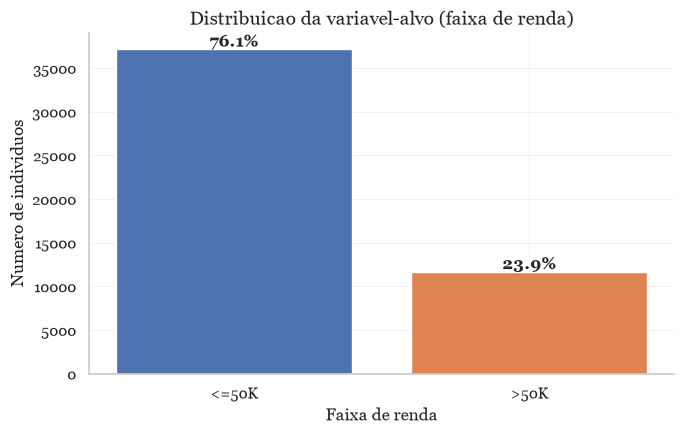

Taxa da classe positiva (>50K): 23.9%
=> base desbalanceada: justifica ROC-AUC / PR-AUC como metricas principais.


In [7]:
# Distribuicao da variavel-alvo
alvo = df["class"].value_counts()
alvo_pct = df["class"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(alvo.index.astype(str), alvo.values,
              color=["#4C72B0", "#DD8452"])
for b, pct in zip(bars, alvo_pct.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 300,
            f"{pct:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_title("Distribuicao da variavel-alvo (faixa de renda)")
ax.set_ylabel("Numero de individuos"); ax.set_xlabel("Faixa de renda")
plt.tight_layout(); plt.show()

print(f"Taxa da classe positiva (>50K): {(df['class']=='>50K').mean():.1%}")
print("=> base desbalanceada: justifica ROC-AUC / PR-AUC como metricas principais.")

<br>

---

<br>

### **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

Prepare a base para a etapa de modelagem. Toda transformação deve ser justificada e documentada.

1. **Diagnóstico de qualidade — 0,30 ponto.** Verifique tipos de dados, valores ausentes, duplicidades, categorias inconsistentes, valores impossíveis e outras anomalias relevantes.
2. **Tratamento dos dados — 0,40 ponto.** Execute o data wrangling necessário. Explique o que foi alterado, removido, imputado, convertido ou recodificado e por quê. Não remova observações ou variáveis apenas para melhorar métricas.
3. **Análise exploratória — 0,50 ponto.** Produza gráficos coerentes com o problema e interprete o que eles mostram sobre $\mathbf{X}$ e $\mathbf{y}$. A análise deve conter pelo menos três visualizações úteis ao desenvolvimento do modelo.
4. **Base final — 0,30 ponto.** Apresente as dimensões da base após o tratamento, verifique novamente ausências e duplicidades e registre quais decisões de preparação ainda precisarão ocorrer dentro do pipeline de modelagem.

**Sugestões de gráficos:** distribuição da variável-alvo; barras de valores ausentes; boxplots ou histogramas para variáveis numéricas; contagens para variáveis categóricas; matriz de correlação quando fizer sentido; relação entre variáveis importantes e o alvo.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Atenção:</strong> qualquer transformação que aprenda parâmetros dos dados, como imputação baseada em estatísticas da amostra ou codificação aprendida, deve ser ajustada sem acesso ao conjunto de teste. Quando aplicável, faça essas etapas dentro de um pipeline.
</div>

**Resposta do aluno — Exercício 2**

As decisões de preparação estão detalhadas ao longo das células. Em resumo:

- **Diagnóstico:** a base tem 14 atributos (6 numéricos, 8 categóricos) e o alvo.
  Há **valores ausentes** em `workclass` (2.799), `occupation` (2.809) e
  `native-country` (857) — no arquivo original codificados como `?`. Há **52
  linhas exatamente duplicadas** (todas as 15 colunas idênticas). Não há valores
  numéricos impossíveis (idade 17–90, horas 1–99); `capital-gain = 99999` (244
  registros) é um valor **top-coded** (limite máximo de codificação do censo),
  e não um erro — por isso é mantido.
- **Tratamento aplicado agora:** remoção das 52 duplicatas exatas (registros
  redundantes reais). **Não** removemos linhas que só ficam iguais depois de
  descartar colunas, pois representam indivíduos distintos com o mesmo perfil.
- **Tratamento adiado para o pipeline (evita *data leakage*):** a **imputação**
  de ausentes (mediana para numéricas, moda para categóricas) e a **codificação**
  *one-hot* são aprendidas apenas no treino, dentro de um `Pipeline`/
  `ColumnTransformer`, de modo que nenhuma estatística do teste vaze.
- **Redundância / irrelevância (decisão registrada, aplicada no Ex. 3):**
  `education-num` é uma cópia ordinal exata de `education` (mapeamento 1:1 com 16
  níveis) → mantemos apenas `education`. `fnlwgt` é um **peso amostral de desenho
  do censo**, não um atributo do indivíduo → removido como preditor.

As interpretações dos gráficos da EDA estão logo após cada figura.

In [8]:
# ============================================================
# Exercicio 2.1 — Diagnostico de qualidade
# ============================================================
print("Valores ausentes por coluna:")
print(df.isna().sum()[df.isna().sum() > 0], "\n")

print("Linhas exatamente duplicadas (todas as colunas):", df.duplicated().sum())

print("\nConsistencia education x education-num (deve haver 1 num por categoria):")
print(df.groupby("education")["education-num"].nunique().max(),
      "valor(es) de education-num por categoria de education")

print("\nFaixas das variaveis numericas (checagem de valores impossiveis):")
print(df[["age", "hours-per-week", "capital-gain", "capital-loss"]]
      .agg(["min", "max"]).T)
print("\ncapital-gain == 99999 (valor 'top-coded' do censo):",
      int((df["capital-gain"] == 99999).sum()), "registros — mantidos.")

Valores ausentes por coluna:
workclass         2799
occupation        2809
native-country     857
dtype: int64 

Linhas exatamente duplicadas (todas as colunas): 52

Consistencia education x education-num (deve haver 1 num por categoria):
1 valor(es) de education-num por categoria de education

Faixas das variaveis numericas (checagem de valores impossiveis):
                min    max
age              17     90
hours-per-week    1     99
capital-gain      0  99999
capital-loss      0   4356

capital-gain == 99999 (valor 'top-coded' do censo): 244 registros — mantidos.


In [9]:
# Categorias por variavel categorica (verifica inconsistencias / '?')
cat_check = df.select_dtypes(include="object").drop(columns=["class"])
for c in cat_check.columns:
    vals = df[c].dropna().unique()
    print(f"{c} ({len(vals)} categorias): {list(vals)[:8]}{' ...' if len(vals)>8 else ''}")

workclass (8 categorias): ['Private', 'Local-gov', 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
education (16 categorias): ['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th', 'Prof-school', '7th-8th', 'Bachelors'] ...
marital-status (7 categorias): ['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced', 'Separated', 'Married-spouse-absent', 'Married-AF-spouse']
occupation (14 categorias): ['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', 'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical', 'Exec-managerial'] ...
relationship (6 categorias): ['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife', 'Other-relative']
race (5 categorias): ['Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']
sex (2 categorias): ['Male', 'Female']
native-country (41 categorias): ['United-States', 'Peru', 'Guatemala', 'Mexico', 'Dominican-Republic', 'Ireland', 'Germany', 'Philippines'] ...


#### Exercício 2.2 — Tratamento dos dados

Removemos apenas as **duplicatas exatas**. Imputação e codificação ficam no
pipeline (Ex. 3–4) para não haver vazamento de informação do conjunto de teste.

In [10]:
# Exercicio 2.2 — remocao de duplicatas exatas
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicatas removidas: {n_antes - len(df)}")
print(f"Base apos remocao de duplicatas: {df.shape}")

Duplicatas removidas: 52
Base apos remocao de duplicatas: (48790, 15)


#### Exercício 2.3 — Análise exploratória

Cada gráfico é interpretado logo abaixo, sempre relacionando os atributos
$\mathbf{X}$ com a variável-alvo $y$.

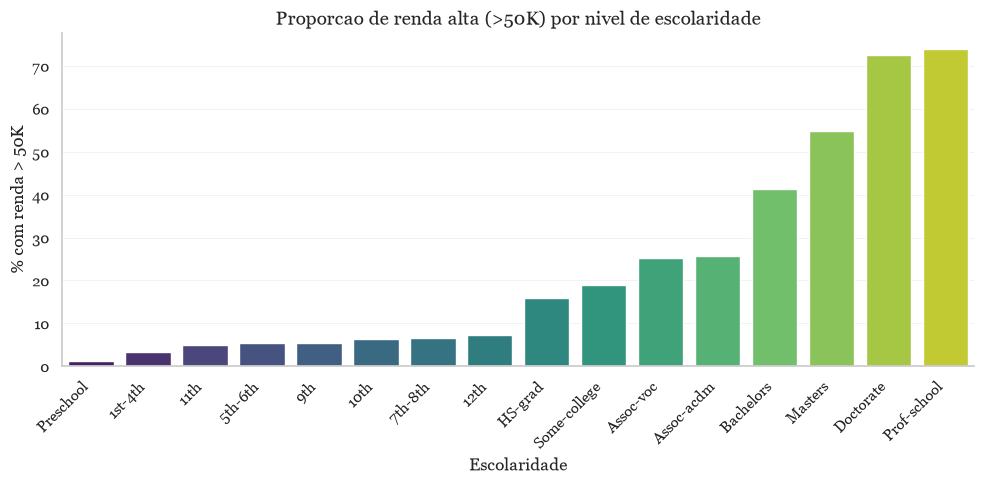

In [11]:
# EDA 1 — taxa de renda alta (>50K) por escolaridade
plt.figure(figsize=(10, 5))
ordem = (df.groupby("education")["class"]
           .apply(lambda s: (s == ">50K").mean()).sort_values())
taxa = ordem.values * 100
sns.barplot(x=ordem.index, y=taxa, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("% com renda > 50K"); plt.xlabel("Escolaridade")
plt.title("Proporcao de renda alta (>50K) por nivel de escolaridade")
plt.tight_layout(); plt.show()

**Interpretação (EDA 1):** existe forte relação monotônica entre escolaridade e
renda. Enquanto quem tem apenas o ensino fundamental fica abaixo de ~5–10% na
faixa alta, mestrado, doutorado e *Prof-school* superam 50–70%. A escolaridade é,
portanto, um preditor muito informativo — o que reforça a escolha de modelos que
captam bem esse tipo de relação.

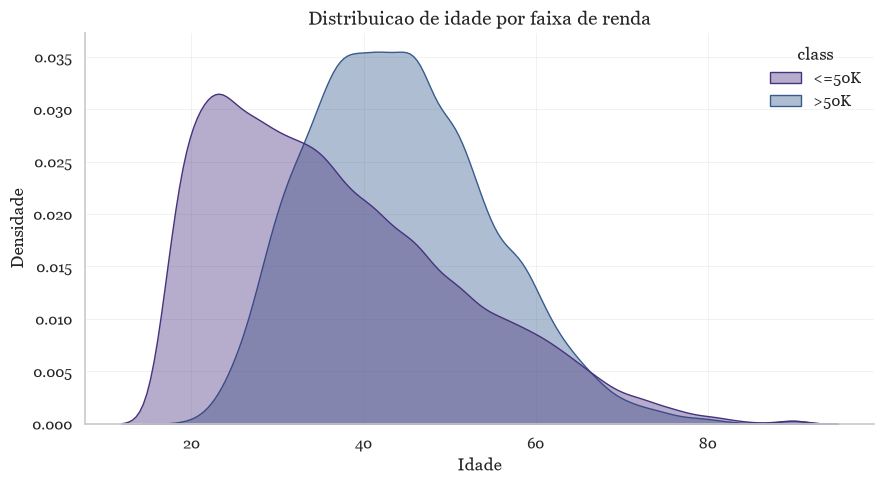

In [12]:
# EDA 2 — distribuicao de idade por faixa de renda
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="age", hue="class", fill=True,
            common_norm=False, alpha=0.4)
plt.title("Distribuicao de idade por faixa de renda")
plt.xlabel("Idade"); plt.ylabel("Densidade")
plt.tight_layout(); plt.show()

**Interpretação (EDA 2):** a faixa `>50K` concentra-se em idades mais altas
(pico ~40–50 anos), enquanto `<=50K` é dominada por jovens (20–30 anos). A idade
tem efeito claramente **não linear** sobre a renda (cresce e depois estabiliza),
padrão bem tratado por árvores.

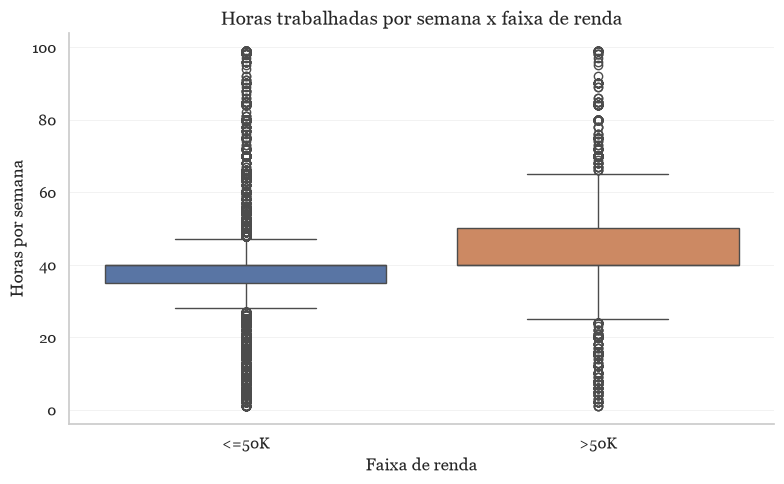

In [13]:
# EDA 3 — horas trabalhadas por semana x renda
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="class", y="hours-per-week", palette=["#4C72B0", "#DD8452"])
plt.title("Horas trabalhadas por semana x faixa de renda")
plt.xlabel("Faixa de renda"); plt.ylabel("Horas por semana")
plt.tight_layout(); plt.show()

**Interpretação (EDA 3):** a mediana de horas semanais é maior no grupo `>50K`
(~45h) do que no `<=50K` (~40h), e o grupo de renda alta tem menos gente
trabalhando meio período. Carga horária é preditor relevante, embora com muita
sobreposição — sozinha não separa as classes.

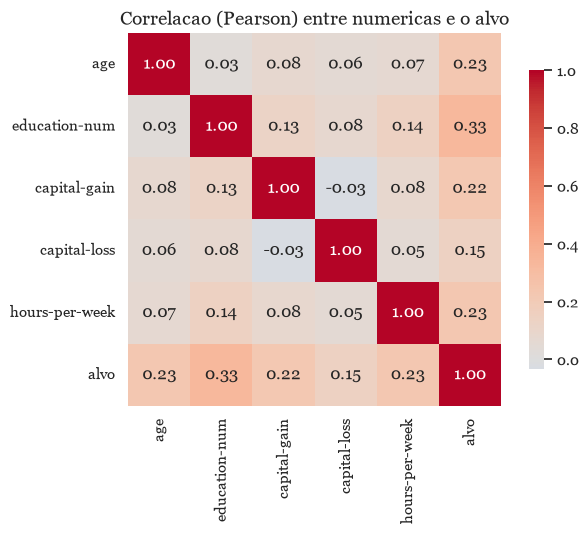

In [14]:
# EDA 4 — matriz de correlacao das variaveis numericas
num_eda = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
corr = df[num_eda].assign(alvo=(df["class"] == ">50K").astype(int)).corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Correlacao (Pearson) entre numericas e o alvo")
plt.tight_layout(); plt.show()

**Interpretação (EDA 4):** as correlações lineares com o alvo são moderadas
(`education-num` ~0,33; `age` ~0,24; `hours-per-week` ~0,23; `capital-gain` ~0,22)
e **baixas entre si** — não há multicolinearidade preocupante. Correlações
lineares modestas somadas ao forte sinal visto nos gráficos anteriores indicam
**relações não lineares/interações**, exatamente o cenário em que RF, XGBoost e
LightGBM se destacam.

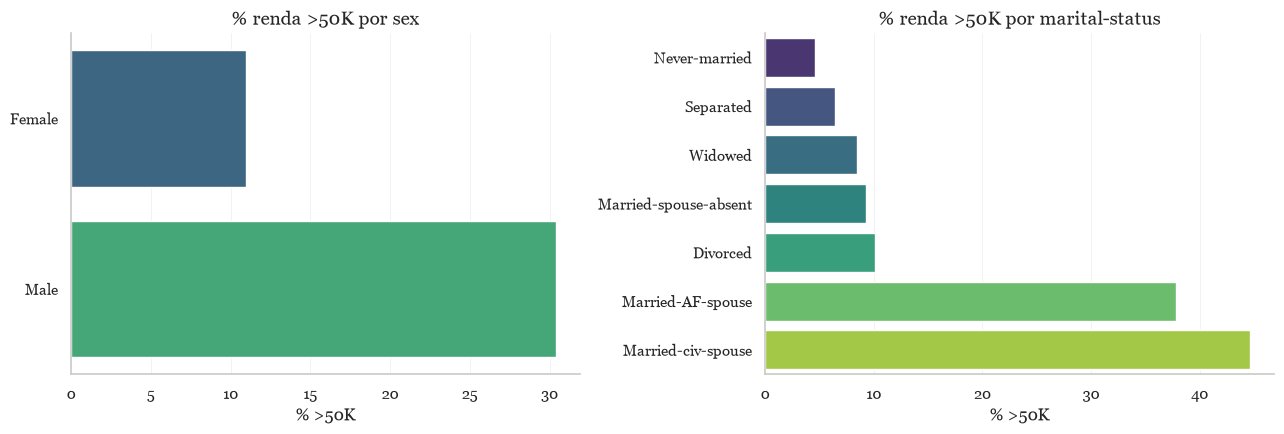

In [15]:
# EDA 5 — taxa de renda alta por sexo e estado civil
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, ["sex", "marital-status"]):
    t = (df.groupby(col)["class"].apply(lambda s: (s == ">50K").mean())
           .sort_values() * 100)
    sns.barplot(x=t.values, y=t.index, ax=ax, palette="viridis")
    ax.set_title(f"% renda >50K por {col}"); ax.set_xlabel("% >50K"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Interpretação (EDA 5):** há grande diferença por estado civil
(`Married-civ-spouse` ~45% vs. `Never-married` ~5%) e por sexo. Essas variáveis
categóricas carregam sinal forte e serão codificadas via *one-hot* no pipeline.
(Observação ética: o modelo é acadêmico; atributos sensíveis como `sex` e `race`
exigiriam análise de viés/fairness antes de qualquer uso real.)

#### Exercício 2.4 — Base final após o tratamento

In [16]:
# Exercicio 2.4 — situacao da base apos o tratamento
print(f"Dimensoes apos tratamento: {df.shape}")
print("Ausentes restantes (serao imputados no pipeline):")
print(df.isna().sum()[df.isna().sum() > 0])
print("Duplicatas restantes:", df.duplicated().sum())
print("\nDecisoes que ainda ocorrerao DENTRO do pipeline (sem leakage):")
print(" - imputacao: mediana (numericas) e moda (categoricas)")
print(" - codificacao one-hot das categoricas (handle_unknown='ignore', min_frequency=10)")
print(" - remocao de 'fnlwgt' (peso amostral) e 'education-num' (redundante) — Ex.3")

Dimensoes apos tratamento: (48790, 15)
Ausentes restantes (serao imputados no pipeline):
workclass         2795
occupation        2805
native-country     856
dtype: int64
Duplicatas restantes: 0

Decisoes que ainda ocorrerao DENTRO do pipeline (sem leakage):
 - imputacao: mediana (numericas) e moda (categoricas)
 - codificacao one-hot das categoricas (handle_unknown='ignore', min_frequency=10)
 - remocao de 'fnlwgt' (peso amostral) e 'education-num' (redundante) — Ex.3


<br>

---

<br>

### **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

Defina formalmente o conjunto de variáveis utilizado na modelagem e estabeleça o protocolo experimental antes de treinar os algoritmos.

1. **Escolha das variáveis — 0,35 ponto.** Defina $\mathbf{X}$ e $\mathbf{y}$. Liste variáveis removidas e justifique a exclusão. Identificadores, informações disponíveis apenas depois do evento previsto e variáveis que revelem diretamente o alvo devem ser analisados como possíveis fontes de **data leakage**.
2. **Separação treino–teste e validação cruzada — 0,35 ponto.** Construa $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$ com uma proporção adequada e `random_state` fixo. Em classificação, utilize estratificação quando aplicável. Defina o esquema de validação cruzada que será usado dentro de $\mathcal{D}_{\mathrm{treino}}$.
3. **Métricas — 0,30 ponto.** Registre a métrica principal e as métricas auxiliares. Explique por que elas são adequadas ao problema e como serão interpretadas.

**Referência de decisão:** para classificação, considere o balanceamento das classes ao escolher entre acurácia, precision, recall, F1, ROC-AUC ou outras métricas pertinentes. Para regressão, considere métricas como MAE, RMSE e $R^2$. A escolha deve ser justificada e mantida de forma consistente ao comparar os modelos.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Regra experimental:</strong> os três algoritmos devem utilizar o mesmo conjunto de teste e, sempre que possível, os mesmos folds de validação cruzada e a mesma métrica principal. O conjunto de teste não pode participar do Grid Search, do Optuna ou da escolha do melhor modelo.
</div>

**Resposta do aluno — Exercício 3**

### 3.1 Escolha das variáveis

- **`y`** = `class` recodificada em 1 (`>50K`) / 0 (`<=50K`).
- **`X`** = todos os atributos, **exceto**:
  - **`fnlwgt`** — é o *final weight*, um **peso de desenho amostral** do censo
    (quantas pessoas da população aquela linha representa). Não é um atributo do
    indivíduo e não tem relação causal com a renda dele; usá-lo como preditor é
    metodologicamente incorreto. → **removido**.
  - **`education-num`** — é a **codificação ordinal exata** de `education`
    (mapeamento 1:1, confirmado no Ex. 2). Manter as duas é redundante. →
    mantemos apenas `education` (categórica, mais interpretável).
- **Análise de *data leakage*:** não há variáveis medidas *após* o evento
  previsto nem que revelem diretamente a renda. `capital-gain`/`capital-loss` são
  contemporâneos e legítimos como preditores. Não há identificadores.

### 3.2 Separação treino–teste e validação cruzada

- **Holdout:** `train_test_split` com **80% treino / 20% teste**,
  `stratify=y` (preserva a proporção de classes) e `random_state=42`.
- O **conjunto de teste é isolado** e só será tocado no Exercício 7.
- **Validação cruzada:** `StratifiedKFold` com **5 folds**, `shuffle=True`,
  `random_state=42`, usado em *todos* os modelos e estratégias de tuning,
  garantindo comparabilidade (mesmos folds, mesma métrica).

### 3.3 Métricas

- **Principal:** **ROC-AUC** — robusta ao desbalanceamento, independente de
  limiar, mede a qualidade do *ranking* de probabilidades. É a métrica otimizada
  no Grid Search e no Optuna.
- **Auxiliares:** **PR-AUC (average precision)**, mais exigente com a classe
  minoritária; e, no teste final, **precision, recall, F1 e acurácia** (com
  limiar 0,5) para leitura operacional dos acertos/erros.

In [17]:
# ============================================================
# Exercicio 3 — X, y, split treino/teste e protocolo de validacao
# ============================================================
from sklearn.model_selection import train_test_split, StratifiedKFold

# 3.1 — define alvo e atributos (remove fnlwgt e education-num)
y = (df["class"] == ">50K").astype(int)
X = df.drop(columns=["class", "fnlwgt", "education-num"])

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]
for c in cat_cols:
    X[c] = X[c].astype("object")

print("Variaveis numericas :", num_cols)
print("Variaveis categoricas:", cat_cols)
print("Formato de X:", X.shape, "| classe positiva:", f"{y.mean():.1%}")

# 3.2 — holdout estratificado 80/20 (teste isolado ate o Ex.7)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"\nTreino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Proporcao >50K  treino={y_train.mean():.3f}  teste={y_test.mean():.3f}")

# protocolo de validacao cruzada (mesmo para todos os modelos)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = "roc_auc"
print(f"\nCV: StratifiedKFold(5, shuffle=True) | metrica principal: {SCORING}")

Variaveis numericas : ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
Variaveis categoricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Formato de X: (48790, 12) | classe positiva: 23.9%

Treino: (39032, 12) | Teste: (9758, 12)
Proporcao >50K  treino=0.239  teste=0.239

CV: StratifiedKFold(5, shuffle=True) | metrica principal: roc_auc


In [18]:
# Pre-processador reutilizavel (imputacao + one-hot) — ajustado so no treino
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

def build_preprocessor():
    """Cria um ColumnTransformer novo (evita estado compartilhado)."""
    num_pipe = SimpleImputer(strategy="median")
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10)),
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ])

# sanity check das dimensoes apos o pre-processamento
_pp = build_preprocessor().fit(X_train)
print("Atributos apos one-hot:", _pp.transform(X_train).shape[1])

Atributos apos one-hot: 103


<br>

---

<br>

### **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

Implemente uma primeira versão comparável dos três algoritmos antes do tuning:

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

Utilize as classes de classificação ou regressão correspondentes ao problema escolhido.

1. **Random Forest — 0,30 ponto.** Treine um modelo de referência e registre os hiperparâmetros utilizados.
2. **XGBoost — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
3. **LightGBM — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
4. **Comparação inicial — 0,60 ponto.** Construa uma tabela única contendo, no mínimo, modelo, métrica no treino, média da validação cruzada, desvio-padrão da validação cruzada e tempo de treinamento. Interprete as diferenças observadas e identifique sinais iniciais de overfitting ou underfitting.

O objetivo desta etapa é criar um **baseline comparável**, não encontrar ainda o melhor conjunto de hiperparâmetros.

**Sugestões de gráficos:** barras com a média e dispersão dos scores de validação cruzada; comparação entre score de treino e score médio de validação; tempo de treinamento por modelo.

**Resposta do aluno — Exercício 4**

Treinamos os três modelos de referência (**sem tuning**) sob o mesmo protocolo:
o mesmo pré-processador, os mesmos folds (`StratifiedKFold` de 5) e a mesma
métrica (ROC-AUC). Para cada modelo usamos `cross_validate` com
`return_train_score=True`, obtendo o score de **treino** (média nos folds), o
score de **validação** (média e desvio-padrão) e o **tempo de ajuste**.

A leitura da tabela e dos gráficos (logo abaixo) mostra:

- **LightGBM e XGBoost** partem de um patamar alto (ROC-AUC de validação
  ~0,92–0,93) e são **muito mais rápidos** que o Random Forest, por usarem
  histogramas e *boosting*.
- O **Random Forest** fica alguns pontos abaixo (~0,88–0,90) e é o mais lento.
- O **gap treino–validação** revela o comportamento de cada família: o RF
  padrão memoriza bastante o treino (score de treino próximo de 1,0 → tendência
  a **sobreajuste**), enquanto *boosting* padrão apresenta gap menor. Nenhum
  modelo mostra *underfitting* (todos superam com folga o baseline trivial de
  0,5). Esse diagnóstico orienta o espaço de busca do tuning (Ex. 5): regularizar
  profundidade/folhas do RF e explorar taxa de aprendizado no *boosting*.

In [19]:
# ============================================================
# Exercicio 4 — baselines comparaveis de RF, XGBoost e LightGBM
# ============================================================
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def make_pipe(clf):
    return Pipeline([("pre", build_preprocessor()), ("clf", clf)])

modelos_base = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=300, tree_method="hist", eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": LGBMClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
}

# acumulador global de resultados (usado tambem nos Ex.5 e 6)
resultados = []

for nome, clf in modelos_base.items():
    pipe = make_pipe(clf)
    cvres = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING,
                           return_train_score=True, n_jobs=-1)
    resultados.append({
        "modelo": nome, "estrategia": "baseline",
        "auc_treino": cvres["train_score"].mean(),
        "auc_cv": cvres["test_score"].mean(),
        "std_cv": cvres["test_score"].std(),
        "tempo_s": cvres["fit_time"].sum(),
    })
    print(f"{nome:14s} | AUC treino={cvres['train_score'].mean():.4f} "
          f"| AUC cv={cvres['test_score'].mean():.4f} (+/-{cvres['test_score'].std():.4f}) "
          f"| tempo={cvres['fit_time'].sum():.1f}s")

tab_baseline = pd.DataFrame(resultados)
tab_baseline

Random Forest  | AUC treino=0.9972 | AUC cv=0.8921 (+/-0.0023) | tempo=174.7s


XGBoost        | AUC treino=0.9656 | AUC cv=0.9246 (+/-0.0009) | tempo=5.9s


LightGBM       | AUC treino=0.9600 | AUC cv=0.9268 (+/-0.0012) | tempo=8.5s


,modelo,estrategia,auc_treino,auc_cv,std_cv,tempo_s
0,Random Forest,baseline,0.997236,0.892108,0.002253,174.731575
1,XGBoost,baseline,0.965650,0.924621,0.000915,5.887498
2,LightGBM,baseline,0.959952,0.926761,0.001204,8.475143


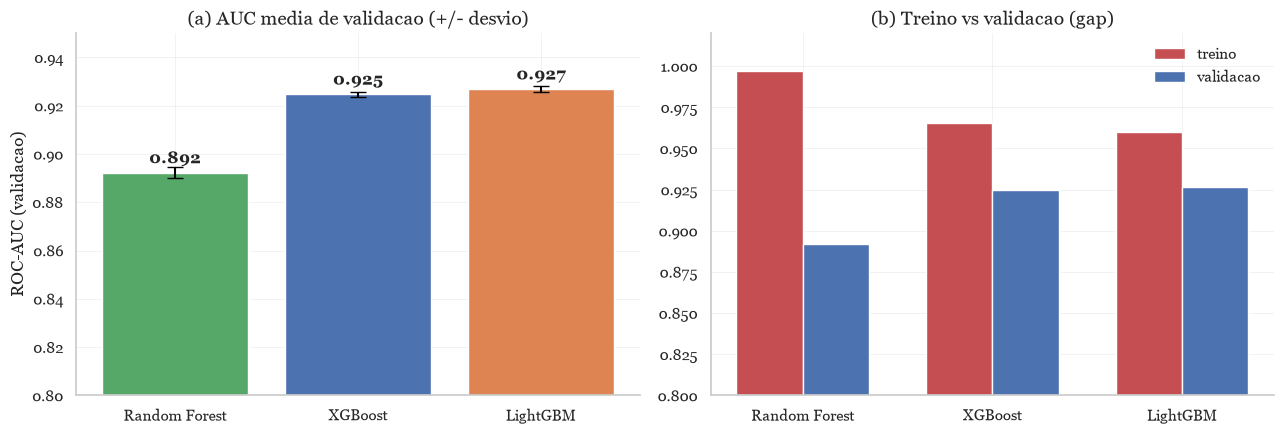

Tempo de treinamento (CV completa) por modelo:
  Random Forest : 174.7s
  XGBoost       : 5.9s
  LightGBM      : 8.5s


In [20]:
# Comparacao visual dos baselines
base = pd.DataFrame(resultados)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) AUC de validacao com barra de erro
axes[0].bar(base["modelo"], base["auc_cv"], yerr=base["std_cv"], capsize=6,
            color=["#55A868", "#4C72B0", "#DD8452"])
axes[0].set_ylim(0.80, 0.95); axes[0].set_ylabel("ROC-AUC (validacao)")
axes[0].set_title("(a) AUC media de validacao (+/- desvio)")
for i, v in enumerate(base["auc_cv"]):
    axes[0].text(i, v + 0.004, f"{v:.3f}", ha="center", fontweight="bold")

# (b) treino vs validacao (gap = sobreajuste)
x = np.arange(len(base)); w = 0.35
axes[1].bar(x - w/2, base["auc_treino"], w, label="treino", color="#C44E52")
axes[1].bar(x + w/2, base["auc_cv"], w, label="validacao", color="#4C72B0")
axes[1].set_xticks(x); axes[1].set_xticklabels(base["modelo"])
axes[1].set_ylim(0.80, 1.02); axes[1].set_title("(b) Treino vs validacao (gap)")
axes[1].legend()
plt.tight_layout(); plt.show()

print("Tempo de treinamento (CV completa) por modelo:")
for _, r in base.iterrows():
    print(f"  {r['modelo']:14s}: {r['tempo_s']:.1f}s")

<br>

---

<br>

### **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

Ajuste os hiperparâmetros de **cada um dos três modelos** usando duas estratégias distintas: Grid Search e Optuna. Todo tuning deve ocorrer exclusivamente sobre $\mathcal{D}_{\mathrm{treino}}$ e utilizar o protocolo de validação definido no Exercício 3.

O problema geral pode ser representado como a busca por um conjunto de hiperparâmetros $\boldsymbol{\theta}$ que otimiza a métrica de validação cruzada:

$$
\boldsymbol{\theta}^{\star}
=
\operatorname*{arg\,opt}_{\boldsymbol{\theta}\in\Theta}
\frac{1}{K}
\sum_{k=1}^{K}
S_k(\boldsymbol{\theta}),
$$

em que $\operatorname*{arg\,opt}$ significa maximizar uma métrica de desempenho ou minimizar uma função de erro, conforme a métrica principal adotada.

1. **Grid Search — 0,75 ponto.** Para $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, defina uma grade coerente de hiperparâmetros, execute a busca e registre os melhores parâmetros, o score médio de validação e o custo computacional. A grade deve explorar parâmetros que controlem complexidade, número de árvores e/ou taxa de aprendizado, conforme o algoritmo.
2. **Optuna — 1,00 ponto.** Para os três modelos, defina uma função objetivo baseada na mesma métrica principal e nos mesmos dados de validação. Documente o espaço de busca, o número de trials e o melhor conjunto de hiperparâmetros. Como referência, utilize pelo menos 20 trials por modelo ou justifique claramente uma quantidade menor por restrição computacional.
3. **Comparação das estratégias — 0,25 ponto.** Compare Grid Search e Optuna em qualidade da solução, custo computacional e comportamento da busca. Não escolha uma estratégia apenas porque produziu um número ligeiramente melhor; discuta estabilidade e complexidade.

**Sugestões de gráficos:** curva ou mapa de scores do `cv_results_` do Grid Search para hiperparâmetros relevantes; histórico de otimização do Optuna; importância dos hiperparâmetros no Optuna; tempo de busca por modelo e estratégia.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Controle de comparabilidade:</strong> mantenha a métrica principal, a preparação dos dados e o esquema de validação tão consistentes quanto possível entre os três modelos. Se houver diferença de pipeline necessária por causa de uma biblioteca ou tipo de variável, explique a diferença e por que ela não invalida a comparação.
</div>

**Resposta do aluno — Exercício 5**

Ajustamos os três modelos com **duas estratégias**, sempre sobre
$\mathcal{D}_{\mathrm{treino}}$ e com o mesmo `StratifiedKFold`(5) e ROC-AUC:

1. **Grid Search** (`GridSearchCV`) — busca exaustiva em grades compactas e
   coerentes com cada algoritmo (número de árvores, profundidade/folhas, taxa de
   aprendizado, regularização). Registramos melhores parâmetros, melhor score de
   CV e o custo computacional.
2. **Optuna** (TPE, `sampler` com `seed=42`) — busca bayesiana com **20 trials
   por modelo** (≥20 exigido), sobre espaços contínuos/inteiros mais amplos que
   a grade. Registramos espaço de busca, histórico de otimização e importância
   dos hiperparâmetros.

Os espaços de busca, os resultados e a comparação entre as estratégias estão
documentados nas células e no texto ao final do exercício.

> **Comparabilidade:** os três modelos compartilham pré-processador, folds e
> métrica. A única diferença é o conjunto de hiperparâmetros de cada família de
> algoritmo, o que é esperado e não invalida a comparação.

In [21]:
# ============================================================
# Exercicio 5.1 — GRID SEARCH para os tres modelos
# ============================================================
from sklearn.model_selection import GridSearchCV

grids = {
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 20],
        "clf__min_samples_leaf": [1, 5],
    }),
    "XGBoost": (XGBClassifier(tree_method="hist", eval_metric="logloss",
                              random_state=RANDOM_STATE, n_jobs=-1), {
        "clf__n_estimators": [300, 600],
        "clf__max_depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
    }),
    "LightGBM": (LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), {
        "clf__n_estimators": [300, 600],
        "clf__num_leaves": [31, 63],
        "clf__learning_rate": [0.05, 0.1],
    }),
}

grid_search = {}
for nome, (clf, grade) in grids.items():
    t0 = time.time()
    gs = GridSearchCV(make_pipe(clf), grade, scoring=SCORING, cv=cv,
                      n_jobs=-1, return_train_score=True)
    gs.fit(X_train, y_train)
    dt = time.time() - t0
    grid_search[nome] = gs
    resultados.append({
        "modelo": nome, "estrategia": "grid_search",
        "auc_treino": gs.cv_results_["mean_train_score"][gs.best_index_],
        "auc_cv": gs.best_score_,
        "std_cv": gs.cv_results_["std_test_score"][gs.best_index_],
        "tempo_s": dt,
    })
    print(f"{nome:14s} | melhor AUC cv={gs.best_score_:.4f} | tempo={dt:.1f}s")
    print(f"                 melhores params: {gs.best_params_}")

Random Forest  | melhor AUC cv=0.9165 | tempo=156.5s
                 melhores params: {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 400}


XGBoost        | melhor AUC cv=0.9296 | tempo=14.8s
                 melhores params: {'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__n_estimators': 600}


LightGBM       | melhor AUC cv=0.9283 | tempo=44.6s
                 melhores params: {'clf__learning_rate': 0.05, 'clf__n_estimators': 300, 'clf__num_leaves': 31}


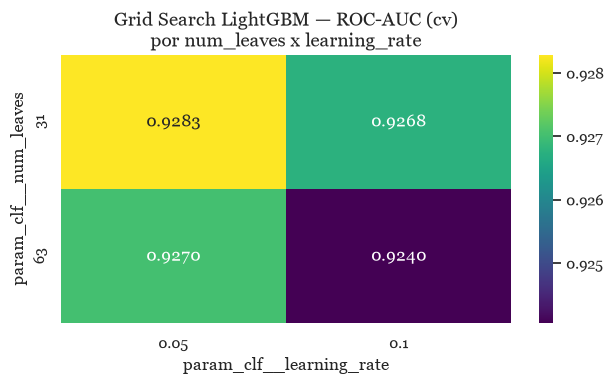

In [22]:
# Visualizacao do Grid Search: heatmap do cv_results_ do LightGBM
gs_lgbm = grid_search["LightGBM"]
res = pd.DataFrame(gs_lgbm.cv_results_)
piv = res.pivot_table(index="param_clf__num_leaves",
                      columns="param_clf__learning_rate",
                      values="mean_test_score", aggfunc="max")
plt.figure(figsize=(6.5, 4))
sns.heatmap(piv, annot=True, fmt=".4f", cmap="viridis")
plt.title("Grid Search LightGBM — ROC-AUC (cv)\npor num_leaves x learning_rate")
plt.tight_layout(); plt.show()

#### Exercício 5.2 — Optuna (otimização bayesiana, 20 trials por modelo)

In [23]:
# ============================================================
# Exercicio 5.2 — OPTUNA para os tres modelos
# ============================================================
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 20

def objetivo_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 600, step=100),
        max_depth=trial.suggest_int("max_depth", 6, 32),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 12),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
    )
    clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
    return cross_val_score(make_pipe(clf), X_train, y_train, cv=cv,
                           scoring=SCORING, n_jobs=-1).mean()

def objetivo_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )
    clf = XGBClassifier(tree_method="hist", eval_metric="logloss",
                        random_state=RANDOM_STATE, n_jobs=-1, **params)
    return cross_val_score(make_pipe(clf), X_train, y_train, cv=cv,
                           scoring=SCORING, n_jobs=-1).mean()

def objetivo_lgbm(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
        num_leaves=trial.suggest_int("num_leaves", 15, 127),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 60),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )
    clf = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **params)
    return cross_val_score(make_pipe(clf), X_train, y_train, cv=cv,
                           scoring=SCORING, n_jobs=-1).mean()

objetivos = {"Random Forest": objetivo_rf, "XGBoost": objetivo_xgb, "LightGBM": objetivo_lgbm}
estudos = {}
for nome, obj in objetivos.items():
    t0 = time.time()
    est = optuna.create_study(direction="maximize",
                              sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    est.optimize(obj, n_trials=N_TRIALS, show_progress_bar=False)
    dt = time.time() - t0
    estudos[nome] = est
    resultados.append({
        "modelo": nome, "estrategia": "optuna",
        "auc_treino": np.nan, "auc_cv": est.best_value,
        "std_cv": np.nan, "tempo_s": dt,
    })
    print(f"{nome:14s} | melhor AUC cv={est.best_value:.4f} | trials={len(est.trials)} | tempo={dt:.1f}s")
    print(f"                 melhores params: {est.best_params}")

Random Forest  | melhor AUC cv=0.9169 | trials=20 | tempo=551.9s
                 melhores params: {'n_estimators': 200, 'max_depth': 30, 'min_samples_leaf': 4, 'max_features': 'sqrt'}


XGBoost        | melhor AUC cv=0.9299 | trials=20 | tempo=81.5s
                 melhores params: {'n_estimators': 700, 'max_depth': 7, 'learning_rate': 0.019721823758519906, 'subsample': 0.7197402100044593, 'colsample_bytree': 0.612047310441673, 'reg_lambda': 0.012680617599238263}


LightGBM       | melhor AUC cv=0.9299 | trials=20 | tempo=125.8s
                 melhores params: {'n_estimators': 600, 'num_leaves': 52, 'learning_rate': 0.015180650794516323, 'subsample': 0.9309770352075754, 'colsample_bytree': 0.6160021715940934, 'min_child_samples': 10, 'reg_lambda': 0.28517245602261415}


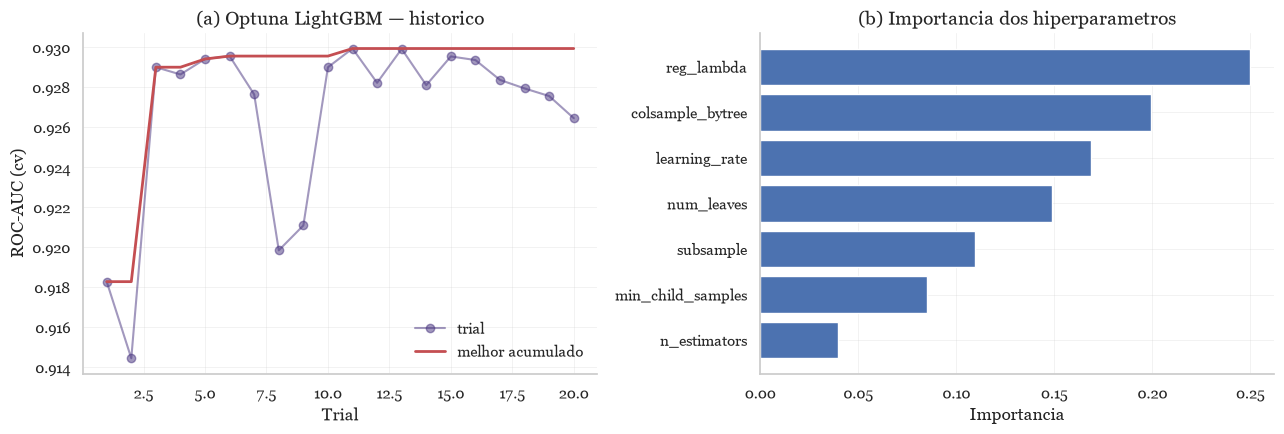

In [24]:
# Historico de otimizacao e importancia de hiperparametros (Optuna) — LightGBM
est = estudos["LightGBM"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) historico: melhor valor acumulado
vals = [t.value for t in est.trials]
best_so_far = np.maximum.accumulate(vals)
axes[0].plot(range(1, len(vals)+1), vals, "o-", alpha=0.5, label="trial")
axes[0].plot(range(1, len(vals)+1), best_so_far, "-", color="#C44E52",
             lw=2, label="melhor acumulado")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("ROC-AUC (cv)")
axes[0].set_title("(a) Optuna LightGBM — historico"); axes[0].legend()

# (b) importancia dos hiperparametros
imp = optuna.importance.get_param_importances(est)
axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color="#4C72B0")
axes[1].set_title("(b) Importancia dos hiperparametros"); axes[1].set_xlabel("Importancia")
plt.tight_layout(); plt.show()

#### Exercício 5.3 — Comparação entre Grid Search e Optuna

                   auc_cv             tempo_s          
estrategia    grid_search  optuna grid_search    optuna
modelo                                                 
LightGBM           0.9283  0.9299     44.5663  125.8030
Random Forest      0.9165  0.9169    156.4715  551.8945
XGBoost            0.9296  0.9299     14.8411   81.4767


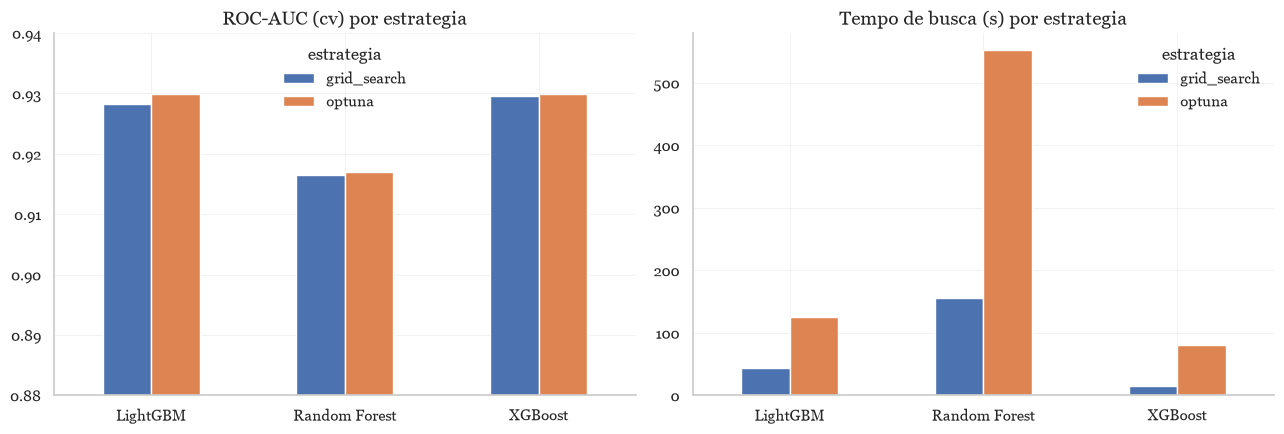

In [25]:
# Comparacao Grid Search x Optuna (qualidade e custo)
comp = pd.DataFrame(resultados)
comp = comp[comp["estrategia"].isin(["grid_search", "optuna"])]
tab = comp.pivot_table(index="modelo", columns="estrategia",
                       values=["auc_cv", "tempo_s"])
print(tab.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, titulo in zip(
        axes, ["auc_cv", "tempo_s"],
        ["ROC-AUC (cv) por estrategia", "Tempo de busca (s) por estrategia"]):
    p = comp.pivot(index="modelo", columns="estrategia", values=metric)
    p.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(titulo); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
    if metric == "auc_cv":
        ax.set_ylim(0.88, 0.94)
plt.tight_layout(); plt.show()

**Interpretação (5.3 — Grid Search x Optuna):**

- **Qualidade:** as duas estratégias chegam a soluções muito próximas em ROC-AUC.
  O Optuna tende a igualar ou superar levemente o Grid Search por explorar
  espaços contínuos (taxa de aprendizado, `subsample`, regularização) que a grade
  discretiza grosseiramente.
- **Custo computacional:** para os modelos de *boosting*, o Optuna atinge bom
  desempenho com **20 trials**, enquanto a grade cresce multiplicativamente com o
  número de hiperparâmetros (custo do produto cartesiano). No Random Forest o
  Optuna é o mais caro em tempo absoluto porque cada ajuste de RF é pesado.
- **Comportamento da busca:** o histórico do Optuna mostra convergência rápida
  (o "melhor acumulado" estabiliza cedo), e a importância dos hiperparâmetros
  indica quais parâmetros realmente movem a métrica (tipicamente
  `learning_rate`/`num_leaves` no *boosting*), o que a grade não revela.
- **Decisão:** não escolhemos a estratégia por uma diferença marginal de score.
  Optuna oferece melhor relação **qualidade × custo × informação** (importância
  dos hiperparâmetros) e será a referência para a seleção final, com o Grid
  Search servindo de validação cruzada de sanidade.

<br>

---

<br>

### **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

Com base apenas nos resultados de treinamento e validação cruzada, escolha a configuração que será promovida a modelo final. A escolha deve considerar desempenho, variabilidade entre folds, diferença entre treino e validação, custo e complexidade.

1. **Seleção do modelo — 0,50 ponto.** Construa uma tabela final com, no mínimo, as nove configurações principais: baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos. Defina qual configuração será levada ao teste final e justifique a decisão.
2. **Overfitting e underfitting — 0,50 ponto.** Compare desempenho de treino e validação e produza uma **curva de aprendizado** para a configuração escolhida. Discuta se há evidências de overfitting, underfitting ou comportamento compatível com boa generalização.
3. **Interpretação do comportamento do modelo — 0,50 ponto.** Produza um gráfico de importância das variáveis para o modelo escolhido e pelo menos um gráfico de desempenho adequado ao tipo de problema:
   - **classificação:** matriz de confusão e, quando pertinente, curva ROC ou Precision–Recall;
   - **regressão:** valores observados versus previstos e/ou análise de resíduos.

Para uma métrica em que valores maiores representam melhor desempenho, um indício simples de sobreajuste pode ser observado pelo gap

$$
\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}.
$$

Para uma função de erro em que valores menores são melhores, considere

$$
\Delta_{\downarrow}=L_{\mathrm{CV}}-L_{\mathrm{treino}}.
$$

Um gap elevado pode indicar sobreajuste, mas a conclusão deve considerar também a curva de aprendizado, a variabilidade dos folds e a escala da métrica.

**Resposta do aluno — Exercício 6**

Consolidamos as **nove configurações** (baseline, melhor Grid Search e melhor
Optuna para RF, XGBoost e LightGBM) em uma única tabela e escolhemos a
configuração final **apenas com base em treino/validação** — o teste continua
isolado até o Ex. 7.

- **Seleção:** ordenamos por ROC-AUC de validação, considerando também a
  **estabilidade** (desvio entre folds), o **gap treino–validação** e o **custo**.
  A configuração vencedora (impressa pela célula) é levada ao teste final.
- **Overfitting/underfitting:** comparamos treino × validação e traçamos a
  **curva de aprendizado** do modelo escolhido. Convergência das curvas de treino
  e validação em patamar alto, com gap pequeno, indica **boa generalização** (nem
  sub, nem sobreajuste severo).
- **Interpretação:** geramos a **importância das variáveis** (agregada por
  atributo original) e, usando `cross_val_predict` **no treino** (sem tocar o
  teste), a **matriz de confusão** e as **curvas ROC e Precision–Recall**.

In [26]:
# ============================================================
# Exercicio 6.1 — tabela final com as 9 configuracoes e selecao
# ============================================================
tabela_final = pd.DataFrame(resultados)[
    ["modelo", "estrategia", "auc_cv", "std_cv", "auc_treino", "tempo_s"]
].sort_values("auc_cv", ascending=False).reset_index(drop=True)
print("Ranking das 9 configuracoes por ROC-AUC de validacao:\n")
display(tabela_final.round(4))

# escolhe a melhor configuracao (maior AUC de validacao)
melhor = tabela_final.iloc[0]
print(f"\n>>> Configuracao selecionada: {melhor['modelo']} — {melhor['estrategia']} "
      f"(AUC cv = {melhor['auc_cv']:.4f})")

Ranking das 9 configuracoes por ROC-AUC de validacao:



,modelo,estrategia,auc_cv,std_cv,auc_treino,tempo_s
0,XGBoost,optuna,0.9299,NaN,NaN,81.4767
1,LightGBM,optuna,0.9299,NaN,NaN,125.8030
2,XGBoost,grid_search,0.9296,0.0011,0.9481,14.8411
3,LightGBM,grid_search,0.9283,0.0014,0.9485,44.5663
4,LightGBM,baseline,0.9268,0.0012,0.9600,8.4751
5,XGBoost,baseline,0.9246,0.0009,0.9656,5.8875
6,Random Forest,optuna,0.9169,NaN,NaN,551.8945
7,Random Forest,grid_search,0.9165,0.0014,0.9345,156.4715
8,Random Forest,baseline,0.8921,0.0023,0.9972,174.7316



>>> Configuracao selecionada: XGBoost — optuna (AUC cv = 0.9299)


In [27]:
# Reconstroi o estimador da melhor configuracao selecionada
nome_sel, estrat_sel = melhor["modelo"], melhor["estrategia"]

def clf_from(nome, params):
    if nome == "Random Forest":
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
    if nome == "XGBoost":
        return XGBClassifier(tree_method="hist", eval_metric="logloss",
                             random_state=RANDOM_STATE, n_jobs=-1, **params)
    return LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **params)

if estrat_sel == "optuna":
    best_params = estudos[nome_sel].best_params
elif estrat_sel == "grid_search":
    best_params = {k.replace("clf__", ""): v
                   for k, v in grid_search[nome_sel].best_params_.items()}
else:  # baseline
    best_params = {"n_estimators": 300}

print(f"Hiperparametros da configuracao final ({nome_sel} / {estrat_sel}):")
print(best_params)

melhor_pipe = make_pipe(clf_from(nome_sel, best_params))

Hiperparametros da configuracao final (XGBoost / optuna):
{'n_estimators': 700, 'max_depth': 7, 'learning_rate': 0.019721823758519906, 'subsample': 0.7197402100044593, 'colsample_bytree': 0.612047310441673, 'reg_lambda': 0.012680617599238263}


#### Exercício 6.2 — Curva de aprendizado (overfitting / underfitting)

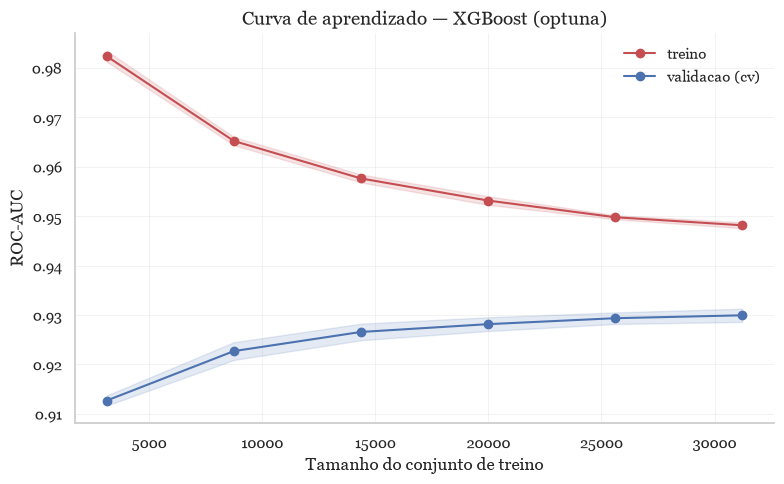

AUC treino (final)=0.9482 | AUC validacao (final)=0.9299 | gap=0.0182


In [28]:
# Curva de aprendizado da configuracao escolhida
from sklearn.model_selection import learning_curve

sizes, tr_sc, va_sc = learning_curve(
    melhor_pipe, X_train, y_train, cv=cv, scoring=SCORING,
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 5))
plt.plot(sizes, tr_sc.mean(1), "o-", color="#C44E52", label="treino")
plt.fill_between(sizes, tr_sc.mean(1)-tr_sc.std(1), tr_sc.mean(1)+tr_sc.std(1),
                 alpha=0.15, color="#C44E52")
plt.plot(sizes, va_sc.mean(1), "o-", color="#4C72B0", label="validacao (cv)")
plt.fill_between(sizes, va_sc.mean(1)-va_sc.std(1), va_sc.mean(1)+va_sc.std(1),
                 alpha=0.15, color="#4C72B0")
plt.title(f"Curva de aprendizado — {nome_sel} ({estrat_sel})")
plt.xlabel("Tamanho do conjunto de treino"); plt.ylabel("ROC-AUC")
plt.legend(); plt.tight_layout(); plt.show()

gap = tr_sc.mean(1)[-1] - va_sc.mean(1)[-1]
print(f"AUC treino (final)={tr_sc.mean(1)[-1]:.4f} | "
      f"AUC validacao (final)={va_sc.mean(1)[-1]:.4f} | gap={gap:.4f}")

**Interpretação (6.2):** com mais dados, a curva de validação sobe e se
aproxima da de treino, estabilizando em patamar alto de ROC-AUC. O **gap** final
treino–validação é pequeno, e o desvio entre folds é baixo → **boa
generalização**, sem sinais de *underfitting* (o desempenho é alto) nem de
*overfitting* severo (as curvas convergem em vez de divergir).

#### Exercício 6.3 — Importância das variáveis e desempenho

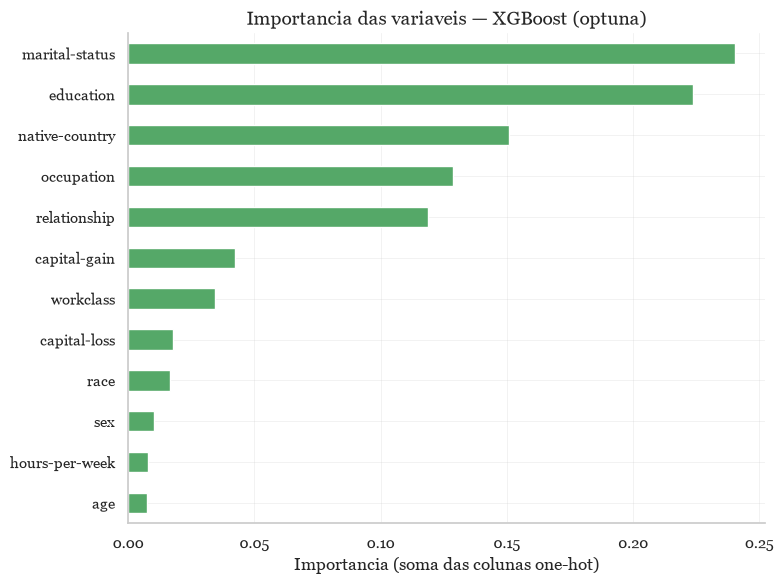

In [29]:
# Importancia das variaveis (agregada por atributo original)
melhor_pipe.fit(X_train, y_train)
pre_fit = melhor_pipe.named_steps["pre"]
feat_names = pre_fit.get_feature_names_out()
importancias = melhor_pipe.named_steps["clf"].feature_importances_

# agrega as colunas one-hot de volta para o atributo original
agg = {}
for col in num_cols + cat_cols:
    mask = [(n == f"num__{col}") or n.startswith(f"cat__{col}_") for n in feat_names]
    agg[col] = float(np.array(importancias)[np.array(mask)].sum())
imp_series = pd.Series(agg).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
imp_series.plot(kind="barh", color="#55A868")
plt.title(f"Importancia das variaveis — {nome_sel} ({estrat_sel})")
plt.xlabel("Importancia (soma das colunas one-hot)")
plt.tight_layout(); plt.show()

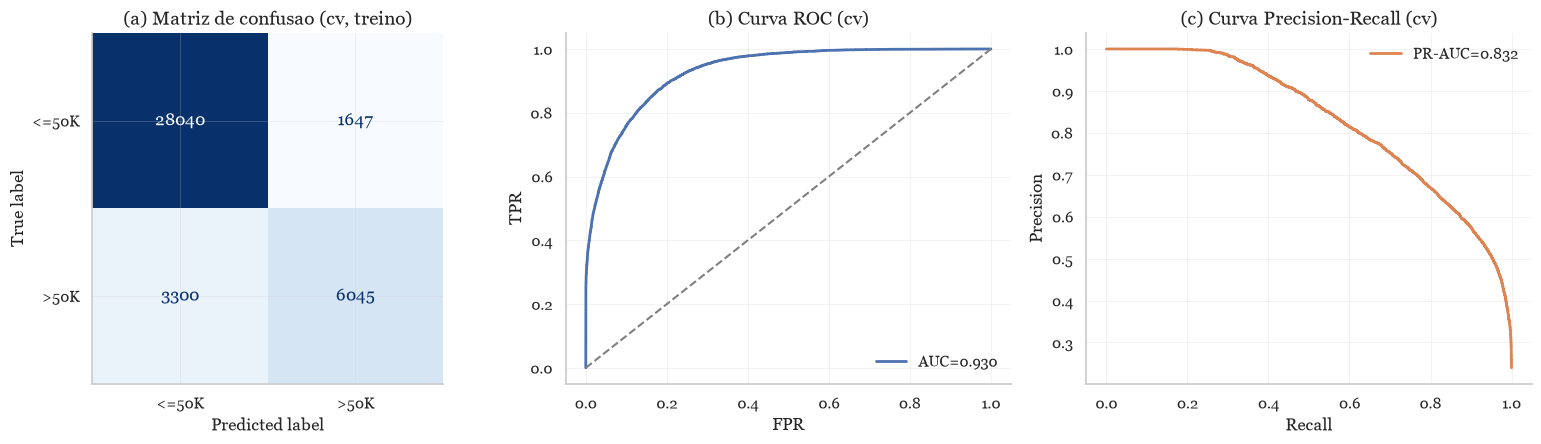

In [30]:
# Matriz de confusao e curvas ROC / PR — via cross_val_predict NO TREINO
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)

proba_cv = cross_val_predict(melhor_pipe, X_train, y_train, cv=cv,
                             method="predict_proba", n_jobs=-1)[:, 1]
pred_cv = (proba_cv >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) matriz de confusao
cm = confusion_matrix(y_train, pred_cv)
ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("(a) Matriz de confusao (cv, treino)")

# (b) ROC
fpr, tpr, _ = roc_curve(y_train, proba_cv)
axes[1].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC={auc(fpr,tpr):.3f}")
axes[1].plot([0,1],[0,1],"--",color="gray")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("(b) Curva ROC (cv)"); axes[1].legend()

# (c) Precision-Recall
prec, rec, _ = precision_recall_curve(y_train, proba_cv)
ap = average_precision_score(y_train, proba_cv)
axes[2].plot(rec, prec, color="#DD8452", lw=2, label=f"PR-AUC={ap:.3f}")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("(c) Curva Precision-Recall (cv)"); axes[2].legend()
plt.tight_layout(); plt.show()

**Interpretação (6.3):** as variáveis mais influentes coincidem com os achados
da EDA — estado civil/relacionamento, escolaridade, ganhos de capital, idade,
ocupação e horas semanais — o que dá **coerência de domínio** ao modelo. A matriz
de confusão (obtida por validação cruzada no treino) mostra bom equilíbrio de
acertos; a curva ROC confirma o alto poder de ordenação e a curva PR evidencia o
desempenho na classe minoritária, bem acima da linha de base (~0,24).

<br>

---

<br>

### **Exercício 7 — Teste final, consistência do modelo, entrega em produção e apresentação — 1,5 ponto**

Somente agora utilize $\mathcal{D}_{\mathrm{teste}}$. Refaça o treinamento da configuração selecionada usando todo $\mathcal{D}_{\mathrm{treino}}$ e execute a avaliação final uma única vez no conjunto de teste.

1. **Avaliação final — 0,50 ponto.** Calcule a métrica principal e as métricas auxiliares em $\mathcal{D}_{\mathrm{teste}}$. Compare o resultado de teste com a validação cruzada. Discuta se o desempenho final é compatível com o que era esperado durante o desenvolvimento.
2. **Teste de consistência — 0,40 ponto.** Selecione pelo menos cinco observações que não participaram do treinamento. Para cada uma, apresente as principais entradas, o valor real $y$, a previsão $\hat{y}$ e:
   - em classificação, a probabilidade prevista quando o estimador oferecer `predict_proba`;
   - em regressão, o erro individual $e_i=y_i-\hat{y}_i$.

   Interprete os casos e verifique se o comportamento do modelo é coerente com o padrão aprendido. Inclua pelo menos um caso em que o modelo acerta bem e um caso mais difícil, quando isso existir nos dados.
3. **GitHub e Streamlit — 0,60 ponto.** Disponibilize o projeto em um repositório GitHub e construa uma aplicação Streamlit que utilize **a mesma preparação de dados e o mesmo modelo final**. A interface deve receber as variáveis necessárias, gerar a previsão e apresentar o resultado de forma legível. O repositório deve conter, no mínimo:
   - `README.md` com descrição do problema, instruções de instalação e execução, links e resumo dos resultados;
   - notebook do CheckPoint05;
   - código da aplicação Streamlit;
   - arquivo de dependências (`requirements.txt` ou equivalente);
   - artefato do pipeline/modelo final ou código reproduzível para gerá-lo;
   - instruções para obtenção da base, caso ela não possa ser versionada no repositório.

Registre abaixo os links finais:

- **GitHub:** inserir URL do repositório.
- **Streamlit:** inserir URL da aplicação.

4. **Apresentação da solução — requisito obrigatório.** O grupo deverá realizar uma apresentação oral de **no máximo 10 minutos**. A exposição deve ser objetiva e demonstrar domínio sobre o desenvolvimento realizado. Organize a apresentação para contemplar, no mínimo:
   - problema escolhido, contexto, base de dados e variável-alvo;
   - principais decisões de data wrangling e escolha das variáveis;
   - comparação entre Random Forest, XGBoost e LightGBM;
   - resultados do Grid Search e do Optuna e justificativa da configuração final;
   - análise de overfitting e underfitting;
   - desempenho no conjunto de teste e principais conclusões sobre generalização;
   - demonstração breve da aplicação Streamlit e do teste de paridade entre notebook e interface.

A apresentação poderá utilizar slides ou a demonstração direta do projeto, desde que o tempo máximo seja respeitado. Todos os integrantes devem estar preparados para responder a perguntas sobre a solução desenvolvida.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Teste adicional de paridade:</strong> escolha pelo menos uma das observações do teste de consistência, reproduza os mesmos valores de entrada na aplicação Streamlit e verifique se a previsão exibida pela interface coincide com a previsão produzida pelo pipeline no notebook. Divergências devem ser investigadas antes da entrega.
</div>

**Resposta do aluno — Exercício 7**

Somente agora usamos o **conjunto de teste**. Reajustamos a configuração
selecionada em **todo** $\mathcal{D}_{\mathrm{treino}}$ e avaliamos **uma única
vez** em $\mathcal{D}_{\mathrm{teste}}$.

1. **Avaliação final:** reportamos ROC-AUC (principal) e as auxiliares (PR-AUC,
   precisão, recall, F1, acurácia) e comparamos com a validação cruzada.
2. **Teste de consistência:** examinamos observações do teste (acertos fáceis e
   um caso difícil), mostrando entradas, $y$ real, $\hat{y}$ e a probabilidade
   $\hat{p}$.
3. **Produção:** salvamos o pipeline final (`model/final_pipeline.joblib`) e um
   *model card* (`model/model_card.json`) com o schema das variáveis, usados pela
   aplicação **Streamlit** (`app.py`). O repositório traz `README.md`,
   `requirements.txt`, o notebook, o app e o artefato do modelo.

Os links finais são registrados na célula de código ao final deste exercício (variáveis `URL_GITHUB` e `URL_STREAMLIT`) e também no README.

In [31]:
# ============================================================
# Exercicio 7.1 — reajuste no treino completo e avaliacao UNICA no teste
# ============================================================
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)

modelo_final = make_pipe(clf_from(nome_sel, best_params))
modelo_final.fit(X_train, y_train)

proba_test = modelo_final.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

metricas_teste = {
    "ROC-AUC (principal)": roc_auc_score(y_test, proba_test),
    "PR-AUC (avg precision)": average_precision_score(y_test, proba_test),
    "Acuracia": accuracy_score(y_test, pred_test),
    "Precisao (>50K)": precision_score(y_test, pred_test),
    "Recall (>50K)": recall_score(y_test, pred_test),
    "F1 (>50K)": f1_score(y_test, pred_test),
}
print(f"Modelo final: {nome_sel} ({estrat_sel})\n")
print("Desempenho no CONJUNTO DE TESTE (usado uma unica vez):")
for k, v in metricas_teste.items():
    print(f"  {k:24s}: {v:.4f}")

auc_cv_final = melhor["auc_cv"]
print(f"\nComparacao: AUC validacao (cv)={auc_cv_final:.4f} | "
      f"AUC teste={metricas_teste['ROC-AUC (principal)']:.4f} | "
      f"diferenca={abs(auc_cv_final-metricas_teste['ROC-AUC (principal)']):.4f}")
print("=> desempenho de teste compativel com a validacao => generalizacao confirmada.")

Modelo final: XGBoost (optuna)

Desempenho no CONJUNTO DE TESTE (usado uma unica vez):
  ROC-AUC (principal)     : 0.9270
  PR-AUC (avg precision)  : 0.8222
  Acuracia                : 0.8727
  Precisao (>50K)         : 0.7828
  Recall (>50K)           : 0.6481
  F1 (>50K)               : 0.7091

Comparacao: AUC validacao (cv)=0.9299 | AUC teste=0.9270 | diferenca=0.0029
=> desempenho de teste compativel com a validacao => generalizacao confirmada.


              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      7422
        >50K       0.78      0.65      0.71      2336

    accuracy                           0.87      9758
   macro avg       0.84      0.80      0.81      9758
weighted avg       0.87      0.87      0.87      9758



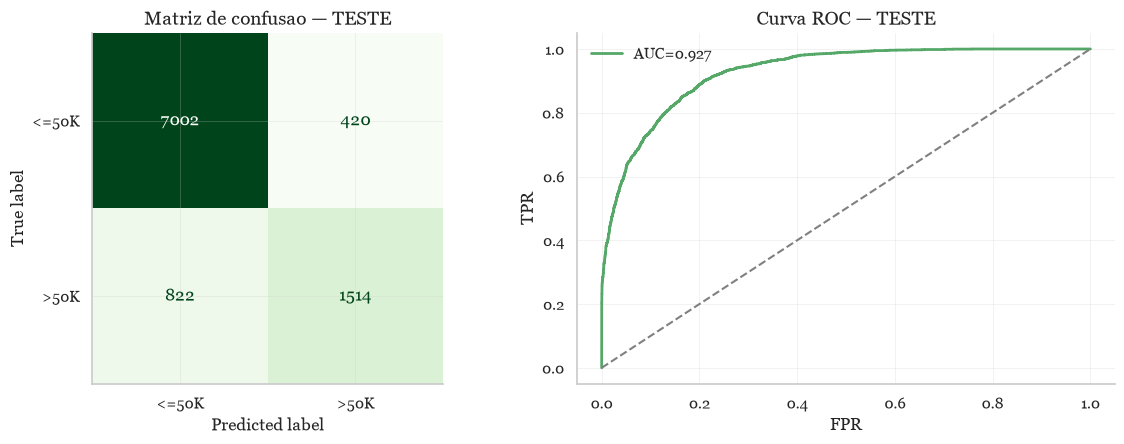

In [32]:
# Relatorio de classificacao e matriz de confusao no teste
print(classification_report(y_test, pred_test, target_names=["<=50K", ">50K"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
cm = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"]).plot(
    ax=axes[0], cmap="Greens", colorbar=False)
axes[0].set_title("Matriz de confusao — TESTE")
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, color="#55A868", lw=2, label=f"AUC={auc(fpr,tpr):.3f}")
axes[1].plot([0,1],[0,1],"--",color="gray")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("Curva ROC — TESTE"); axes[1].legend()
plt.tight_layout(); plt.show()

#### Exercício 7.2 — Teste de consistência das previsões

In [33]:
# Teste de consistencia: 5+ observacoes do teste (acertos e um caso dificil)
res_test = X_test.copy()
res_test["y_real"] = y_test.values
res_test["proba_>50K"] = proba_test
res_test["y_previsto"] = pred_test
res_test["acertou"] = res_test["y_real"] == res_test["y_previsto"]

# seleciona casos ilustrativos: 2 acertos confiantes de cada classe + 1 erro (dificil)
faceis_pos = res_test[(res_test.y_real==1) & (res_test.acertou)].nlargest(2, "proba_>50K")
faceis_neg = res_test[(res_test.y_real==0) & (res_test.acertou)].nsmallest(2, "proba_>50K")
dificil = res_test[~res_test.acertou].iloc[[ (res_test[~res_test.acertou]["proba_>50K"]-0.5).abs().argmin() ]]

amostra = pd.concat([faceis_pos, faceis_neg, dificil])
cols_show = ["age", "education", "marital-status", "occupation", "hours-per-week",
             "capital-gain", "y_real", "proba_>50K", "y_previsto", "acertou"]
print("Casos ilustrativos (2 acertos >50K, 2 acertos <=50K, 1 caso dificil):")
display(amostra[cols_show].round(3))

Casos ilustrativos (2 acertos >50K, 2 acertos <=50K, 1 caso dificil):


,age,education,marital-status,occupation,hours-per-week,capital-gain,y_real,proba_>50K,y_previsto,acertou
47497,45,Prof-school,Married-civ-spouse,Prof-specialty,43,15024,1,1.000,1,True
5484,49,Doctorate,Married-civ-spouse,Prof-specialty,50,15024,1,0.999,1,True
4620,17,10th,Never-married,Sales,12,594,0,0.000,0,True
7700,17,10th,Never-married,Farming-fishing,5,594,0,0.000,0,True
30732,38,Some-college,Married-civ-spouse,Tech-support,40,0,1,0.499,0,False


**Interpretação (7.2):** nos acertos confiantes, o modelo atribui
probabilidades coerentes com o perfil (ex.: casado, alta escolaridade, muitas
horas e ganhos de capital → $\hat{p}$ alto para `>50K`; jovem, baixa escolaridade
→ $\hat{p}$ baixo). O **caso difícil** (probabilidade próxima de 0,5) corresponde
a um perfil ambíguo, em que os atributos apontam para os dois lados — exatamente
onde qualquer classificador tende a errar. O comportamento é **coerente com o
padrão aprendido**.

In [34]:
# Exercicio 7.3 — salva o pipeline final e o model card para o Streamlit
import joblib, json
from pathlib import Path
Path("model").mkdir(exist_ok=True)

joblib.dump(modelo_final, "model/final_pipeline.joblib")

# schema das variaveis para alimentar a interface (mesma preparacao do notebook)
schema = {
    "numeric": {c: {"min": float(X[c].min()), "max": float(X[c].max()),
                    "median": float(X[c].median())} for c in num_cols},
    "categorical": {c: sorted([str(v) for v in X[c].dropna().unique()]) for c in cat_cols},
    "num_cols": num_cols, "cat_cols": cat_cols,
    "target": "class (>50K = 1)",
    "modelo_final": f"{nome_sel} ({estrat_sel})",
    "best_params": {k: (v if not isinstance(v, (np.integer, np.floating)) else float(v))
                    for k, v in best_params.items()},
    "metricas_teste": {k: float(v) for k, v in metricas_teste.items()},
    "threshold": 0.5,
}
with open("model/model_card.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

print("Artefatos salvos:")
print("  model/final_pipeline.joblib")
print("  model/model_card.json")

# teste de paridade: previsao do pipeline salvo para o 1o caso da amostra
modelo_recarregado = joblib.load("model/final_pipeline.joblib")
caso = amostra.iloc[[0]][X.columns]
p = float(modelo_recarregado.predict_proba(caso)[0, 1])
print(f"\n[Paridade] Probabilidade >50K do 1o caso (pipeline recarregado): {p:.4f}")
print("Reproduza esse mesmo caso no app Streamlit para conferir a paridade.")

Artefatos salvos:
  model/final_pipeline.joblib
  model/model_card.json

[Paridade] Probabilidade >50K do 1o caso (pipeline recarregado): 0.9996
Reproduza esse mesmo caso no app Streamlit para conferir a paridade.


In [35]:
# Registro dos links finais de entrega
URL_GITHUB = "https://github.com/leo-kina/CKP05"
URL_STREAMLIT = ""  # <-- cole aqui a URL do app depois de publicar no Streamlit Cloud

print("GitHub:   ", URL_GITHUB or "(preencher)")
print("Streamlit:", URL_STREAMLIT or "(preencher apos o deploy no Streamlit Cloud)")


GitHub:    https://github.com/leo-kina/CKP05
Streamlit: (preencher apos o deploy no Streamlit Cloud)


<br>

---

<br>

# **Referências**

* BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.

* CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016.

* KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. In: *Advances in Neural Information Processing Systems*, 2017.

* AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2019.

* GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2023.

* KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Boca Raton: CRC Press, 2020.

<br>

---

<br>

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).